# Homework: Build MoE Transformer


This homework is built on top of the `Build Your Own Tiny Transformer` homework.
The main task is to implement RoPE and MoE layers and add them to the transformer model that you have built in the previous homework. The data and train loop remained almost unchanged.

## Recommended runtime

This notebook trains in **∼10 minutes on a Colab T4 GPU**. Make sure to
switch the runtime type to **GPU** (*Runtime → Change runtime type → T4 GPU*).
It will also run on CPU, just much more slowly.


In [1]:
import math
import requests
import unittest

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Fixed seed so your loss curves are reproducible. Do not change this before
# submitting — we want everyone to see the same numbers.
torch.manual_seed(1337)


Using device: cuda


We'll use the same dataset **Tiny Shakespeare**, that was used in the previous homework.

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url, timeout=30).text

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]

def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

# 90 / 10 train / validation split (no shuffling — it's one long document).
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]

## Hyperparameters


In [3]:
# Model
block_size = 128   # max context length (how many tokens the model sees at once)
n_embd     = 192   # embedding / residual stream dimension
n_head     = 6     # number of attention heads (n_embd must be divisible by n_head)
n_layer    = 4     # number of Transformer blocks
dropout    = 0.1

# new parameters
hid_dim         = 4 * n_embd    # Intermediate size used in MLP layer: n_embd -> hid_dim -> n_embd
exp_hid_dim     = hid_dim // 2  # Intermediate size of Expert in MoE layer
num_experts     = 8             # Numeber of experts
top_k           = 2             # Number of activated experts at every layer
capacity_factor = 1.25

# Training
batch_size      = 64
learning_rate   = 3e-4
max_iters       = 3000
eval_interval   = 100
eval_iters      = 200   # how many batches to average val loss over


In [4]:
def get_batch(split: str):
    """Sample a random batch of (x, y) pairs.

    For each of `batch_size` examples we pick a random start index `i` into the
    split and return:
        x = tokens[i : i + block_size]
        y = tokens[i + 1 : i + block_size + 1]   # x shifted by one position
    so that position `t` of `y` is the next-token target for position `t` of `x`.
    """
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i : i + block_size]         for i in ix])
    y = torch.stack([d[i + 1 : i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")

## Model components

Use this implementations from your previous homework:

1. `MultiHeadSelfAttention`
2. `FeedForward`
3. `Block`
4. `TinyTransformerLM`

In the current homework you need to implement modules:

1. `RoPE`
2. `MoE`

Additionally, you need to change the blocks above. Their new names:

1. `MultiHeadSelfAttentionRope`
2. `ExpertFeedForward`
3. `BlockMoe`
4. `TinyMoeLM`

### 1. Implementing Rotary Position Embeddings (RoPE)

#### Objective
In this assignment, you will implement the RoPE layer from scratch, handling the frequency caching, tensor manipulation, and the final rotary application on Query and Key tensors.

#### Background Refresher
RoPE encodes absolute positional information by rotating the query and key representations at each position $m$ by an angle proportional to its position.

To do this, we compute a set of inverse frequencies $\theta_i$ for each dimension pair in the attention head:

$$\theta_i = \text{base}^{-2i/d}$$

We then rotate the features by applying the following transformation:

$$x_{\text{rotated}} = (x \odot \cos(m\theta)) + (\text{rotate_half}(x) \odot \sin(m\theta))$$

#### Your Tasks

1. **Precompute the Frequencies:** In your module's `__init__`, compute the inverse frequencies using the standard base of $10000$. Generate the sinusoidal grid for $\cos$ and $\sin$ up to a defined `max_seq_len` and register them as PyTorch buffers so they do not require gradients.
2. **Implement the Rotation Helper:** Write a `rotate_half(x)` function. This function should slice the input tensor in half along its final dimension (the head dimension) and return a new tensor where the halves are swapped and the second half is negated: $[-x_2, x_1]$.
3. **The Forward Pass:** Implement the `forward(q, k)` method. It must dynamically slice your cached $\cos$ and $\sin$ buffers to match the exact sequence length of the incoming queries and keys, broadcast the shapes correctly, and apply the rotary math.

#### Implementation Hints
* While you can implement RoPE using PyTorch's complex number types, for this assignment, please stick to standard real-number tensor manipulation (using the `rotate_half` approach) as it is the standard practice in modern transformer codebases.
* You need to use formula (34) from the original paper for this implementation.

Original paper: https://arxiv.org/abs/2104.09864


In [5]:
class RoPE(nn.Module):
    def __init__(self, dim: int, max_seq_len: int, base: int = 10000.0):
        super().__init__()
        # Inverse frequencies: theta_i = base^(-2i/d) for i in [0, dim/2)
        # Each pair of adjacent dimensions shares one frequency, so we need dim//2 values.
        # Shape: (dim // 2,)
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)

        # Precompute and cache the full (max_seq_len, dim) cos/sin tables.
        # outer(positions, inv_freq) -> (max_seq_len, dim//2)
        # Duplicate along the last axis so that rotate_half works seamlessly: (max_seq_len, dim)
        t     = torch.arange(max_seq_len).float()         # position indices 0 .. max_seq_len-1
        freqs = torch.outer(t, inv_freq)                  # (max_seq_len, dim // 2)
        emb   = torch.cat([freqs, freqs], dim=-1)         # (max_seq_len, dim)

        # Register as buffers: moved to the right device with .to(device), not trained.
        self.register_buffer("cos_cached", emb.cos())     # (max_seq_len, dim)
        self.register_buffer("sin_cached", emb.sin())     # (max_seq_len, dim)

    def rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        """Split last dim in half and return [-x2, x1].

        Given x = [x1 | x2] along the final axis, this returns [-x2 | x1].
        Together with the cos/sin rotation this implements the orthogonal 2-D
        rotation for every dimension pair without using complex numbers.
        """
        x1 = x[..., : x.shape[-1] // 2]   # first half
        x2 = x[..., x.shape[-1] // 2 :]   # second half
        return torch.cat([-x2, x1], dim=-1)

    def forward(self, q, k):
        # q, k: (B, n_head, T, head_dim)
        T = q.shape[-2]

        # Slice cached tables to current sequence length, then broadcast over batch / heads.
        # unsqueeze(0).unsqueeze(0) adds the B and n_head dims for free broadcasting.
        cos = self.cos_cached[:T].unsqueeze(0).unsqueeze(0)  # (1, 1, T, head_dim)
        sin = self.sin_cached[:T].unsqueeze(0).unsqueeze(0)  # (1, 1, T, head_dim)

        # Apply rotary embedding (formula 34 from https://arxiv.org/abs/2104.09864):
        #   x_rotated = x * cos(m*theta) + rotate_half(x) * sin(m*theta)
        # This is an orthogonal rotation so vector magnitudes are preserved.
        q = (q * cos) + (self.rotate_half(q) * sin)
        k = (k * cos) + (self.rotate_half(k) * sin)

        return q, k


#### ✅ Check yourself — RoPE

Unit tests for RoPE module

In [6]:
class TestRoPE(unittest.TestCase):
    def setUp(self):
        self.batch_size = 2
        self.num_heads = 4
        self.seq_len = 10
        self.head_dim = 16

        self.rope = RoPE(dim=self.head_dim, max_seq_len=128)

        self.q = torch.randn(self.batch_size, self.num_heads, self.seq_len, self.head_dim)
        self.k = torch.randn(self.batch_size, self.num_heads, self.seq_len, self.head_dim)

    def test_rotate_half(self):
        """Test if the tensor is split and rotated correctly: [-x2, x1]"""
        x = torch.tensor([[[[1.0, 2.0, 3.0, 4.0]]]])

        expected_out = torch.tensor([[[[-3.0, -4.0, 1.0, 2.0]]]])

        out = self.rope.rotate_half(x)

        self.assertEqual(out.shape, x.shape)
        self.assertTrue(torch.allclose(out, expected_out),
          "rotate_half did not produce the expected [-x2, x1] swap.")

    def test_forward_norm_preservation(self):
        """
        Mathematical proof test: Rotation matrices are orthogonal.
        Applying RoPE should rotate the vector in space, but the magnitude (L2 norm)
        of the vector MUST remain completely unchanged.
        """
        q_rot, k_rot = self.rope(self.q, self.k)

        self.assertEqual(q_rot.shape, self.q.shape, "Rotated Query shape mismatch.")
        self.assertEqual(k_rot.shape, self.k.shape, "Rotated Key shape mismatch.")

        # Calculate the L2 norm (magnitude) along the head_dim
        original_norm = torch.linalg.norm(self.q, dim=-1)
        rotated_norm = torch.linalg.norm(q_rot, dim=-1)

        self.assertTrue(torch.allclose(original_norm, rotated_norm, atol=1e-5),
          "RoPE altered the magnitude of the vectors. It should only rotate them.")


unittest.main(argv=[''], exit=False)

..
----------------------------------------------------------------------
Ran 2 tests in 0.042s

OK


In [7]:
class MultiHeadSelfAttentionRope(nn.Module):
    """Causal multi-head self-attention with RoPE.

    Identical to the hw3 MultiHeadSelfAttention except:
    - No learned positional embedding (RoPE injects position inside this module).
    - RoPE is applied to q and k after the multi-head reshape, before dot-product.
    """
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head   = n_head
        self.head_size = n_embd // n_head
        self.n_embd   = n_embd

        # Single linear projects x to Q, K, V in one shot (bias=False: LayerNorm before adds shift)
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)

        # Output projection recombines all heads back to the residual stream
        self.out_proj = nn.Linear(n_embd, n_embd)

        # Lower-triangular causal mask: future positions become -inf before softmax
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

        self.attn_dropout  = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # RoPE replaces the learned pos_emb from hw3; one instance per attention layer
        self.rope = RoPE(self.head_size, max_seq_len=block_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape

        # Project and split into queries, keys, values — each shape (B, T, C)
        q, k, v = self.qkv(x).split(self.n_embd, dim=-1)

        # Reshape to (B, n_head, T, head_size) so each head is processed independently
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # Inject positional information by rotating q and k (v is left unrotated)
        q, k = self.rope(q, k)

        # Scaled dot-product attention scores: (B, n_head, T, T)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_size)

        # Zero out the upper triangle so each position only attends to past tokens
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))

        att = F.softmax(scores, dim=-1)
        att = self.attn_dropout(att)

        # Weighted sum over values, then merge all heads back to (B, T, C)
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)

        return self.resid_dropout(self.out_proj(y))


### 2. Implementing a Mixture of Experts (MoE) Layer

#### Objective
In this assignment, you will implement a Top-$K$ Sparse Mixture of Experts (MoE) layer. You will replace a standard dense Feed-Forward Network (FFN) with a routed expert system, incorporating capacity limits, token dropping, and the fine-grained expert architecture popularized by DeepSeek.

#### Background Refresher
Standard Transformer layers pass every token through the same massive Feed-Forward Network. A sparse MoE layer, instead, uses a smaller **Router** network to send each token to a subset of smaller FFNs called **Experts**.

In this assignment, we will use a **DeepSeek-style fine-grained expert scheme**. To maintain the same compute budget as a standard MoE model, we will halve the hidden dimension of the experts (`exp_hid_dim`), but double the total number of experts (e.g., using 8 experts instead of 4).

Because hardware requires fixed tensor sizes, experts cannot process an infinite number of tokens. We must enforce an **Expert Capacity**. If an expert receives too many tokens, the excess tokens are "dropped" (ignored by that expert), and we track this as a **Drop Rate** metric.

#### Your Tasks

1. **Re-use your FeedForward Block:** You will use the `FeedForward` class (Linear $\rightarrow$ GELU $\rightarrow$ Linear $\rightarrow$ Dropout) from your previous homework as the base for your experts.
2. **Initialize the MoE Layer:** In your `__init__`, create a linear router (mapping the embedding dimension to the number of experts, without bias) and an `nn.ModuleList` containing your `ExpertFeedForward` experts.
3. **Calculate Capacity:** At the start of your `forward` pass, calculate the maximum token capacity per expert using this formula:
   $$\text{Capacity} = \text{int}\left(\frac{\text{total_tokens} \times \text{top_k}}{\text{num_experts}} \times \text{capacity_factor}\right)$$
4. **Implement Routing Logic:** Calculate the routing weights. You **must** follow this exact order of operations:
   * Pass the flattened inputs through the router to get logits.
   * Apply Softmax to the logits.
   * Select the Top-$K$ values and indices (we will use $K=2$).
   * **Normalize** the selected Top-$K$ weights so that they sum to $1.0$ for each token.
5. **Dispatch and Token Dropping:** Iterate through your experts. For each expert:
   * Find which tokens were routed to it.
   * If the number of assigned tokens exceeds the expert's `capacity`, slice the assignment tensors to truncate the excess tokens. Track how many tokens were dropped.
   * Pass the valid tokens through the expert, multiply the output by the normalized routing weights, and accumulate the results in an output tensor.
6. **Calculate Drop Rate:** Compute the final drop rate for the batch:
   $$\text{Drop Rate} = \frac{\text{total_dropped_tokens}}{\text{total_tokens} \times \text{top_k}}$$
   Return both the final processed tensor and the drop rate metric.

DeepSeekMoE Paper: https://arxiv.org/pdf/2401.06066. You should implement the Figure 2 (b) scheme.


In [8]:
# Using the same block from the previous homework with a few small tweaks.
class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear -> GELU -> Linear -> Dropout."""
    def __init__(self, n_embd: int, hid_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, hid_dim),
            nn.GELU(),
            nn.Linear(hid_dim, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


In [9]:
class MoE(nn.Module):
    """Top-K Sparse Mixture of Experts with capacity limits and token dropping.

    Implements the DeepSeek fine-grained expert scheme (Figure 2b):
    experts use half the hidden dimension of a standard FFN so doubling their
    count keeps the total parameter count comparable.
    """
    def __init__(
        self,
        n_embd: int,
        dropout: float,
        num_experts: int,
        top_k: int,
        capacity_factor: float,
    ):
        super().__init__()
        self.num_experts     = num_experts
        self.top_k           = top_k
        self.capacity_factor = capacity_factor

        # Router: one score per expert, no bias for cleaner routing signal
        self.router = nn.Linear(n_embd, num_experts, bias=False)

        # Fine-grained expert hidden dim: hid_dim//2 = (4*n_embd)//2 = 2*n_embd
        # Halving the width and doubling the count preserves total compute.
        exp_hid_dim = 2 * n_embd
        self.experts = nn.ModuleList([
            FeedForward(n_embd, exp_hid_dim, dropout)
            for _ in range(num_experts)
        ])

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, C = x.shape
        total_tokens = B * T  # every token in the batch is routed independently

        # Flatten to (total_tokens, C) for token-level routing
        x_flat = x.view(total_tokens, C)

        # Maximum number of tokens each expert may process.
        # If more tokens are assigned, the excess are "dropped" (skipped).
        capacity = int(total_tokens * self.top_k / self.num_experts * self.capacity_factor)

        # ------------------------------------------------------------------
        # Routing: assign each token to its top-k experts
        # ------------------------------------------------------------------
        router_logits = self.router(x_flat)                    # (total_tokens, num_experts)
        router_probs  = F.softmax(router_logits, dim=-1)       # softmax over experts

        # Select the top-k expert indices and their raw probabilities
        topk_weights, topk_indices = torch.topk(router_probs, self.top_k, dim=-1)
        # topk_weights / topk_indices: (total_tokens, top_k)

        # Normalize the selected weights so they sum to 1 per token.
        # This ensures the output is a proper convex combination of expert outputs.
        topk_weights = topk_weights / topk_weights.sum(dim=-1, keepdim=True)

        # ------------------------------------------------------------------
        # Dispatch: route tokens to experts, enforce capacity, accumulate results
        # ------------------------------------------------------------------
        output        = torch.zeros_like(x_flat)  # final output accumulator
        total_dropped = 0

        for expert_idx, expert in enumerate(self.experts):
            # Boolean mask: which (token, top_k slot) pairs chose this expert
            expert_mask = (topk_indices == expert_idx)   # (total_tokens, top_k)

            # Positions of all (token, slot) pairs assigned to this expert
            token_idx, slot_idx = expert_mask.nonzero(as_tuple=True)

            num_assigned = token_idx.shape[0]

            # Enforce capacity: drop excess tokens (first-assigned, first-served)
            if num_assigned > capacity:
                total_dropped += num_assigned - capacity
                token_idx = token_idx[:capacity]
                slot_idx  = slot_idx[:capacity]

            if token_idx.shape[0] == 0:
                continue  # this expert receives no tokens this batch

            # Routing weight for each dispatched token, shaped for broadcasting
            weights = topk_weights[token_idx, slot_idx].unsqueeze(-1)  # (assigned, 1)

            # Run tokens through the expert and accumulate the weighted result
            expert_out = expert(x_flat[token_idx])         # (assigned, C)
            output.index_add_(0, token_idx, expert_out * weights)

        # Drop rate: fraction of routed (token, slot) assignments that were dropped
        drop_rate = total_dropped / (total_tokens * self.top_k)

        return output.view(B, T, C), drop_rate


#### ✅ Check yourself — Mixture-of-Experts

In [10]:
class TestMoE(unittest.TestCase):
    def setUp(self):
        self.batch_size = 2
        self.seq_len = 16
        self.n_embd = 64
        self.num_experts = 8
        self.top_k = 2
        self.x = torch.randn(self.batch_size, self.seq_len, self.n_embd)

    def test_forward_shapes_and_nans(self):
        """Test if the forward pass outputs the correct shapes and valid numbers."""
        moe = MoE(
            n_embd=self.n_embd,
            dropout=0.0,
            num_experts=self.num_experts,
            top_k=self.top_k,
            capacity_factor=1.25
        )

        out, drop_rate = moe(self.x)

        self.assertEqual(out.shape, self.x.shape, "MoE output shape must exactly match the input shape.")
        self.assertFalse(torch.isnan(out).any(), "MoE output contains NaNs. Check your routing softmax and normalization.")
        self.assertTrue(isinstance(drop_rate, float) or drop_rate.dim() == 0, "Drop rate should be a scalar/float.")

    def test_zero_drop_rate(self):
        """Test that a massive capacity factor results in exactly 0 dropped tokens."""
        moe = MoE(
            n_embd=self.n_embd,
            dropout=0.0,
            num_experts=self.num_experts,
            top_k=self.top_k,
            capacity_factor=5.0   # very big value
        )

        _, drop_rate = moe(self.x)
        self.assertEqual(drop_rate, 0.0, "Drop rate should be exactly 0.0 when capacity_factor is very high.")

    def test_forced_drop_rate(self):
        """Test that a tiny capacity factor successfully forces tokens to be dropped."""

        moe = MoE(
            n_embd=self.n_embd,
            dropout=0.0,
            num_experts=self.num_experts,
            top_k=self.top_k,
            capacity_factor=0.1   # capacity_factor=0.1 means experts only have 10% of the room they need
        )

        _, drop_rate = moe(self.x)

        self.assertTrue(drop_rate > 0.0, "Drop rate must be > 0 when capacity_factor is severely restricted.")
        self.assertTrue(drop_rate > 0.5, "Drop rate should be very high when capacity is restricted to 0.1.")

unittest.main(argv=[''], exit=False)

.....
----------------------------------------------------------------------
Ran 5 tests in 0.070s

OK


### 3. Modified transformer block


In [11]:
class BlockMoe(nn.Module):
    """Pre-norm Transformer block."""
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadSelfAttentionRope(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.moe = MoE(
            n_embd=n_embd,
            dropout=dropout,
            num_experts=num_experts,
            top_k=top_k,
            capacity_factor=capacity_factor,
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = x + self.attn(self.ln1(x))
        moe_out, drop_rate = self.moe(self.ln2(x))
        x = x + moe_out

        return x, drop_rate


### The full language model definition

#### Notes:
- Do not forget to get rid of positional embeddings; we are replacing them with RoPE
- Calculate `avg_drop_rate` before returning it

In [12]:
class TinyMoeLM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        n_layer: int,
        block_size: int,
        dropout: float,
    ):
        super().__init__()
        self.block_size = block_size

        # Token embedding only — RoPE inside each attention layer handles position.
        # (No pos_emb here, unlike the hw3 TinyTransformerLM.)
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.drop       = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            BlockMoe(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        # Final layer norm stabilises the residual stream before the classifier head
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, (
            f"Sequence length {T} exceeds block_size {self.block_size}. "
            "Did you forget to crop the context in generate()?"
        )

        # Token embeddings (B, T, C); positional info is injected by RoPE inside each block
        x = self.drop(self.token_emb(idx))

        # Run through each MoE block and collect per-layer drop rates for monitoring
        layer_drop_rates = []
        for block in self.blocks:
            x, drop_rate = block(x)
            layer_drop_rates.append(drop_rate)

        # Final layer norm, then project to per-token vocabulary logits
        x      = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # Flatten (B, T) into N for F.cross_entropy
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))

        # Calculate the average drop rate for this forward pass
        avg_drop_rate = sum(
            dr.item() if isinstance(dr, torch.Tensor) else dr
            for dr in layer_drop_rates
        ) / len(layer_drop_rates)

        return logits, loss, avg_drop_rate

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Autoregressively extend idx by max_new_tokens tokens."""
        self.eval()
        for _ in range(max_new_tokens):
            # Crop to block_size: both the causal mask and RoPE cache are bounded by it
            idx_cond = idx[:, -self.block_size:]

            logits, _, _ = self(idx_cond)

            # Only the last position's logits predict the next token
            logits   = logits[:, -1, :]           # (B, vocab_size)
            probs    = F.softmax(logits, dim=-1)  # convert to probabilities
            next_idx = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx      = torch.cat([idx, next_idx], dim=1)

        return idx


### Full-model sanity check

If any of these fail, fix them before training — you'll just waste time
otherwise.


In [13]:
# --- Forward pass check ---
_test_model = TinyMoeLM(
    vocab_size=vocab_size,
    n_embd=64, n_head=4, n_layer=2,
    block_size=block_size, dropout=0.0,
).to(device)

_xb, _yb = get_batch("train")
_logits, _loss, _ = _test_model(_xb, _yb)

print("logits.shape:", tuple(_logits.shape))
print("loss:        ", f"{_loss.item():.4f}")
print("expected ~:  ", f"{math.log(vocab_size):.4f}")

assert _logits.shape == (batch_size, block_size, vocab_size), "Wrong logits shape!"
assert abs(_loss.item() - math.log(vocab_size)) < 0.5, (
    "Loss is suspiciously far from log(vocab_size). An untrained model should "
    "be nearly uniform — check your logits aren't being scaled strangely."
)

# --- Generate check ---
_ctx = torch.tensor([[0, 1, 2]], dtype=torch.long, device=device)
_out = _test_model.generate(_ctx, max_new_tokens=5)

assert _out.shape == (1, 3 + 5), f"Expected shape (1, 8), got {tuple(_out.shape)}"
assert (_out >= 0).all() and (_out < vocab_size).all(), "Generated tokens are outside the vocabulary!"
assert torch.equal(_out[:, :3], _ctx), "generate() must not modify the prefix context."

# Context longer than block_size must still work — tests the crop in TODO 5a.
_long_ctx = torch.zeros((1, block_size + 10), dtype=torch.long, device=device)
try:
    _test_model.generate(_long_ctx, max_new_tokens=3)
except AssertionError as e:
    raise AssertionError(
        "generate() failed with a context longer than block_size. "
        "Did you forget to crop idx to the last self.block_size tokens?"
    ) from e

del _test_model, _xb, _yb, _logits, _loss, _ctx, _out, _long_ctx
print("\n✅ Full-model sanity check passed (forward + generate)")


logits.shape: (64, 128, 65)
loss:         4.1935
expected ~:   4.1744

✅ Full-model sanity check passed (forward + generate)


## 5. Training

Nothing to implement here — just run the cells. Training should take a few
minutes on a GPU. You should see the train loss drop to below **1.2**
and the validation loss is slightly below **1.5**.

Pay attention to the drop rate metric. It shouldn't increase significantly. Values higher than **20%** after the first **100** iterations are suspicious.


In [14]:
@torch.no_grad()
def estimate_loss(model) -> dict[str, dict[str, float]]:
    """Average loss over `eval_iters` batches from each split."""
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(eval_iters)
        drop_rates = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss, drop_rate = model(x, y)
            losses[k] = loss.item()
            drop_rates[k] = drop_rate.item() if isinstance(drop_rate, torch.Tensor) else drop_rate
        out[split] = {
            "loss": losses.mean().item(),
            "drop_rate": drop_rates.mean().item()
        }
    model.train()
    return out


In [15]:
model = TinyMoeLM(
    vocab_size=vocab_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    block_size=block_size,
    dropout=dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f} M")

assert round(n_params/1e6, 2) <= 5.4, "We have 8 half-sized experts, which means \
the total size of the model shouldn't be more than 4 times bigger than the original model size."

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


Model parameters: 5.36 M


In [16]:
history = {
    "iter": [],
    "train_loss": [],
    "val_loss": [],
    "train_drop_rate": [],
    "val_drop_rate": [],
}

for it in range(max_iters + 1):
    if it % eval_interval == 0 or it == max_iters:
        out_dict = estimate_loss(model)
        history["iter"].append(it)
        history["train_loss"].append(out_dict["train"]["loss"])
        history["val_loss"].append(out_dict["val"]["loss"])
        history["train_drop_rate"].append(out_dict["train"]["drop_rate"] * 100)
        history["val_drop_rate"].append(out_dict["val"]["drop_rate"]  * 100)
        print(
            f"iter {it:5d} | \
train loss {out_dict['train']['loss']:.4f} | \
val loss {out_dict['val']['loss']:.4f} | \
train drop rate {100 * out_dict['train']['drop_rate']:.1f}% | \
val drop rate {100 * out_dict['train']['drop_rate']:.1f}%"
        )

    xb, yb = get_batch("train")
    _, loss, drop_rates = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

iter     0 | train loss 4.2286 | val loss 4.2311 | train drop rate 31.6% | val drop rate 31.6%
iter   100 | train loss 2.3933 | val loss 2.4039 | train drop rate 12.8% | val drop rate 12.8%
iter   200 | train loss 2.0174 | val loss 2.0673 | train drop rate 8.3% | val drop rate 8.3%
iter   300 | train loss 1.7853 | val loss 1.8947 | train drop rate 7.2% | val drop rate 7.2%
iter   400 | train loss 1.6597 | val loss 1.8216 | train drop rate 6.1% | val drop rate 6.1%
iter   500 | train loss 1.5732 | val loss 1.7403 | train drop rate 6.5% | val drop rate 6.5%
iter   600 | train loss 1.5177 | val loss 1.6954 | train drop rate 6.4% | val drop rate 6.4%
iter   700 | train loss 1.4738 | val loss 1.6499 | train drop rate 6.2% | val drop rate 6.2%
iter   800 | train loss 1.4380 | val loss 1.6296 | train drop rate 5.8% | val drop rate 5.8%
iter   900 | train loss 1.4078 | val loss 1.6058 | train drop rate 5.7% | val drop rate 5.7%
iter  1000 | train loss 1.3891 | val loss 1.5940 | train drop rate

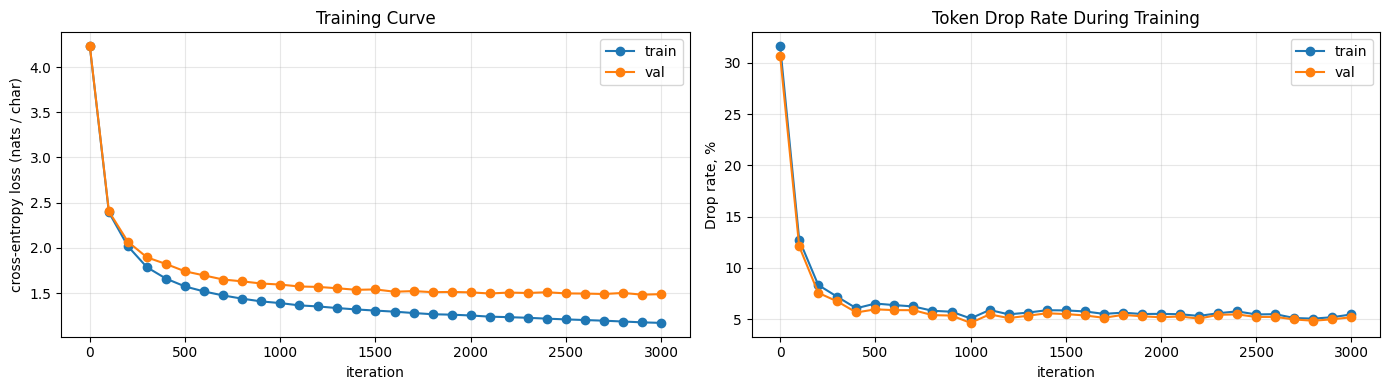

In [17]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

# --- Left Graph: Training Curve (Loss) ---
ax1.plot(history["iter"], history["train_loss"], label="train", marker="o")
ax1.plot(history["iter"], history["val_loss"],   label="val",   marker="o")
ax1.set_xlabel("iteration")
ax1.set_ylabel("cross-entropy loss (nats / char)")
ax1.set_title("Training Curve")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Right Graph: Token Drop Rate ---
ax2.plot(history["iter"], history["train_drop_rate"], label="train", marker="o")
ax2.plot(history["iter"], history["val_drop_rate"],   label="val",   marker="o")
ax2.set_xlabel("iteration")
ax2.set_ylabel("Drop rate, %")
ax2.set_title("Token Drop Rate During Training")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Let's calculate perplexity

In [18]:
out_dict = estimate_loss(model)

train_nll, val_nll = out_dict["train"]['loss'], out_dict["val"]['loss']
train_ppl, val_ppl = math.exp(train_nll), math.exp(val_nll)
val_bpc = val_nll / math.log(2)

baseline_nll = math.log(vocab_size)
baseline_ppl = vocab_size
baseline_bpc = baseline_nll / math.log(2)

print(f"{'':22s} {'nll (nats)':>12s} {'perplexity':>12s} {'bpc':>8s}")
print(f"{'Uniform baseline':22s} {baseline_nll:12.4f} {baseline_ppl:12.2f} {baseline_bpc:8.2f}")
print(f"{'Train (your model)':22s} {train_nll:12.4f} {train_ppl:12.2f} {train_nll / math.log(2):8.2f}")
print(f"{'Val   (your model)':22s} {val_nll:12.4f} {val_ppl:12.2f} {val_bpc:8.2f}")

print(f"\n→ Your model is {baseline_ppl / val_ppl:.1f}× better than a uniform guesser "
      f"at predicting the next character.")


                         nll (nats)   perplexity      bpc
Uniform baseline             4.1744        65.00     6.02
Train (your model)           1.1721         3.23     1.69
Val   (your model)           1.4857         4.42     2.14

→ Your model is 14.7× better than a uniform guesser at predicting the next character.


## Generate samples


In [19]:
# Seed the generator with a single token. In our sorted char vocabulary
# token 0 is the newline character, which is a natural place to start a
# Shakespeare sample (most lines begin with a speaker name after a newline).
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500)[0].tolist()
print(decode(generated))



icrro'd mosstlces faints more shedtach the sount a
faust: his brother's lent purposa--asstent;'
A'aitind aits,' charp, your see; I in the sui
Hair of his brats, aboKing Richard's rotten.
Farewell, my graigh,' and the veil I hear.
Madamper, my lord!
I kneel to be, orrection, and full me fore;
Put out mad for sin will full dost not alted.

GREGORY:
Harry, get up go into your suitor?

BENVOLIO:
May come myselOx Exeter, and it blets me now than
I would have been instires and every death
Had queen th


### **Homework scores (50 Points Total)**

**1. RoPE Implementation (15 Points)**
* **Full 15 Points:** The RoPE layer is fully implemented.

**2. Mixture of Experts (MoE) Layer (25 Points)**
* **Core Functionality (15 Points):** The MoE layer successfully calculates routing logits, applies the Top-$K$ softmax, normalizes the selected weights so they sum to 1, passes tokens through the DeepSeek-style experts, and reconstructs the output tensor to match the original input shape perfectly.
* **Token Dropping (10 Points):** The capacity limit is accurately calculated and enforced. Excess tokens are correctly truncated, and the final drop rate metric is calculated and returned accurately.

**3. Model Training & Target Loss (10 Points)**
* **Achieving Target Loss (10 Points):** The full model successfully integrates both the RoPE and MoE layers, runs the training loop without crashing or producing `NaN`s, and converges to the specified target loss. The final token drop rate must remain under 15%.